# GitHub Repository Analytics
### Take-Home Assessment for Senior Analytics Engineer
The goal is to build a reliable data foundation to analyze and optimize the company's development flow using GitHub data (pull requests, commits, reviews), and to create a KPI focused on improving teams’ collaboration. 

Pipeline extracts GitHub activity from [`pandas-dev/pandas`](https://github.com/pandas-dev/pandas) , transforms it with dbt, and displays key engineering KPIs.

## Notebook Structure

1. **Technical Stack** - tools and technologies used  
2. **Pipeline Design Overview** - architecture and data flow  
3. **Data Model & Structure** - key datasets, table grains, and relationships  
4. **KPI Definitions & Results** - workflow metrics derived from the modeled data  
5. **Data Quality & Validation** - tests, filtering rules, and integrity checks
6. **Production Improvements** - what needs to change before this goes live  
7. **Appendix: Analytical Details** - how thresholds were derived from the actual data

---
## 1. Technical Stack

The pipeline uses a lightweight analytics engineering stack, making it possible to build a complete data product with minimal infrastructure.

| Tool | Role |
|------|------|
| **Python** | Extract data from the GitHub REST API; load raw JSON into DuckDB |
| **DuckDB** | Local analytical database - fast, zero-infrastructure, good for prototyping |
| **dbt-core + dbt-duckdb** | Layered SQL transformations with built-in tests |
| **Jupyter + pandas + seaborn** | Analysis, visualisation |

The full pipeline runs locally with a single `python run_pipeline.py && dbt run`.

---
## 2. Pipeline Design Overview

**Source:** [`pandas-dev/pandas`](https://github.com/pandas-dev/pandas) via GitHub REST API       
**Scope:** Pull requests, reviews, commits, issues, `2025-01-01` onward


**GitHub REST API**    
→ **Python extraction**: pagination + rate-limit handling   
→ **DuckDB raw_data**: raw JSON payloads + _extracted_at    
→ **dbt staging**: parse JSON, cast types, deduplicate labels      
→ **dbt intermediate**: unified contributor spine across all 4 sources    
→ **dbt marts**: fact & dimension tables (bot-filtered, UTC → Amsterdam)  
→ **dbt KPIs**: pre-aggregated metrics, one row per period × dimension    
→ **Jupyter**: analysis & charts       

**Key design decisions:**
* **Idempotent loading**: to keep things simple and reliable, the extraction pipeline now uses a **full refresh** approach (DELETE + INSERT on every run). In prod, it would be better to use **incremental** loading based on `updated_at`.
* **Raw JSON storage**: the full API response is stored in its original JSON format, with an added `_extracted_at` field.
* **Configurable target**: you can change `REPO_OWNER` and `REPO_NAME` in `extraction/config.py` to point at any public repository.
* **UTC in staging, Amsterdam in marts**: clear separation; you can easily change the timezone in one place

### Python source files

| File | What it does |
|------|-------------|
| [`run_pipeline.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/run_pipeline.py) | Entry point, orchestrates the full extraction and loading sequence |
| [`database/init_db.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/database/init_db.py) | Creates the `raw_data` schema and tables on first run |
| [`extraction/config.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/extraction/config.py) | Repo target (`REPO_OWNER`, `REPO_NAME`) and date range settings |
| [`extraction/github_client.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/extraction/github_client.py) | GitHub REST API client - handles pagination and rate-limit retries, used by all extractors |
| [`extraction/extractors/pull_requests.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/extraction/extractors/pull_requests.py) | Fetches PR list, then enriches each with per-PR stats (additions, deletions, files changed) |
| [`extraction/extractors/issues.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/extraction/extractors/issues.py) | Fetches issues, filtering out PRs that also appear in the `/issues` endpoint |
| [`extraction/extractors/commits.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/extraction/extractors/commits.py) | Fetches commits |
| [`extraction/extractors/reviews.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/extraction/extractors/reviews.py) | Fetches reviews for every PR |
| [`extraction/loader.py`](https://github.com/anikonorova/github_repository_analytics/blob/main/extraction/loader.py) | Idempotent loader, DELETE + INSERT raw JSON into DuckDB |

---
## 3. Data Model & Structure

| Layer | Model | Grain | Notes |
|-------|-------|-------|-------|
| Staging | [`stg_pull_requests`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/staging/stg_pull_requests.sql) | 1 row per PR | |
| Staging | [`stg_reviews`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/staging/stg_reviews.sql) | 1 row per review | |
| Staging | [`stg_issues`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/staging/stg_issues.sql) | 1 row per issue | |
| Staging | [`stg_commits`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/staging/stg_commits.sql) | 1 row per commit | |
| Intermediate | [`int_github__contributors_spine`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/intermediate/int_github__contributors_spine.sql) | 1 row per contributor | Deduped across all 4 sources |
| Mart | [`fct_github__pull_requests`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/marts/fct_github__pull_requests.sql) | 1 row per PR | Draft PRs & bots excluded; cycle time + review timing |
| Mart | [`fct_github__issues`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/marts/fct_github__issues.sql) | 1 row per issue | Bots excluded; resolution time + is_bug flag |
| Mart | [`dim_github__contributors`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/marts/dim_github__contributors.sql) | 1 row per contributor | Activity counts across all entities |
| KPI | [`kpi_cycle_time`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/marts/kpi/kpi_cycle_time.sql) | month × pr_size | Small & medium only (large PRs too sparse for a monthly median) |
| KPI | [`kpi_time_to_first_review`](https://github.com/anikonorova/github_repository_analytics/tree/main/dbt_project/models/marts/kpi#:~:text=3%20days%20ago-,kpi_time_to_first_review.sql,-create%20kpi%20dbt) | month | Human reviews only |
| KPI | [`kpi_bug_resolution_time`](https://github.com/anikonorova/github_repository_analytics/tree/main/dbt_project/models/marts/kpi#:~:text=3%20days%20ago-,kpi_bug_resolution_time.sql,-create%20kpi%20dbt) | quarter | Completed bugs only |
| KPI | [`kpi_bug_resolution_buckets`](https://github.com/anikonorova/github_repository_analytics/blob/main/dbt_project/models/marts/kpi/kpi_bug_resolution_buckets.sql) | week × bucket | Full resolution distribution |

**Contributor identity** - the same person can appear as a PR author, reviewer, committer, and issue author. A shared surrogate key (`contributor_key`) ties them together through a contributor spine built in the intermediate layer.

---
## 4. KPI Definitions & Results

Three KPIs covering different stages of the development workflow:

- **PR Cycle Time** - how long it takes to ship code (open → merge)
- **Time to First Review** - how quickly the team responds to review requests
- **Bug Resolution Time** - how fast reported bugs get fixed

In [45]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

conn = duckdb.connect("../database/analytics.db")

### KPI 1 **PR Cycle Time**

**Definition:** median hours from PR opened → merged    
**Excludes:** draft PRs, bot authors, PRs open >30 days (outliers), large PRs (<15/month not enough for a stable median)  
**Split by PR size:** small (≤50 lines) and medium (51–250 lines)   

**Why splitting by size matters:** Using only a single median would not show if changes come from faster processing or a different mix of PR types. Small PRs usually move faster, while medium ones take longer to review.

I group PRs as small (up to 50 lines), medium (51–250 lines), and large (over 250 lines) based on practical experience; these can be adjusted for the company standards.

Originally, I wanted to use percentiles, but most PRs are small (the median is just 31 lines), so it didn’t make much sense. 

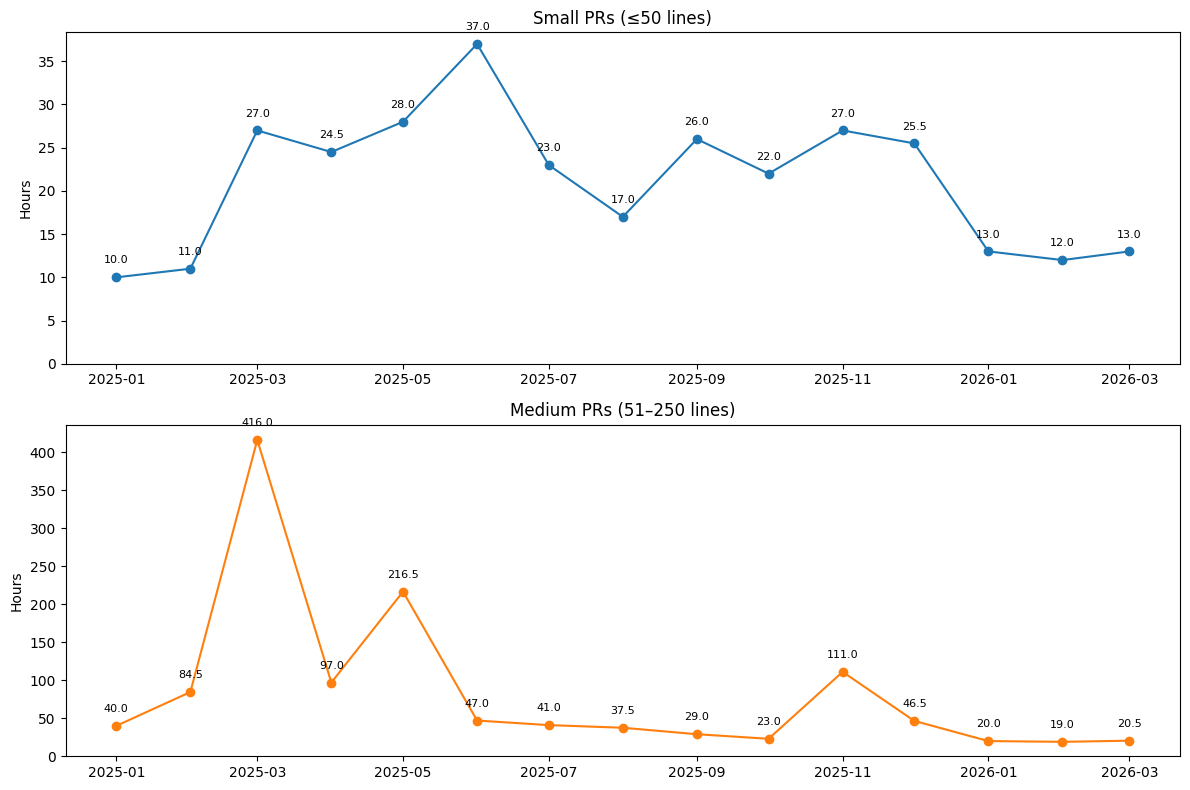

In [33]:
df_cycle = conn.sql("""
    SELECT creation_month, pr_size, median_cycle_time_hours
    FROM main_kpi.kpi_cycle_time
    WHERE median_cycle_time_hours IS NOT NULL
    ORDER BY creation_month, pr_size
""").df()

pivot = df_cycle.pivot(index="creation_month", columns="pr_size", values="median_cycle_time_hours")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

small = pivot["small"]
ax1.plot(small.index, small.values, color="tab:blue", marker="o")
ax1.set_title("Small PRs (≤50 lines)")
ax1.set_ylabel("Hours")
ax1.set_ylim(bottom=0)
ax1.tick_params(axis="x")
for month, val in small.items():
    ax1.annotate(f"{val:.1f}", xy=(month, val), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8)

medium = pivot["medium"]
ax2.plot(medium.index, medium.values, color="tab:orange", marker="o")
ax2.set_title("Medium PRs (51–250 lines)")
ax2.set_ylabel("Hours")
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="x")
for month, val in medium.items():
    ax2.annotate(f"{val:.1f}", xy=(month, val), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

### KPI 2 **Time to First Review**

**Definition:** median hours from PR opened → first human review submitted  
**Excludes:** bot reviewers, PRs with no reviews    
**24h benchmark:** used as a simple operational reference - roughly one working day

The percentage chart gives extra insight, making it easy to spot months when the team fell behind, even if the median looks fine.

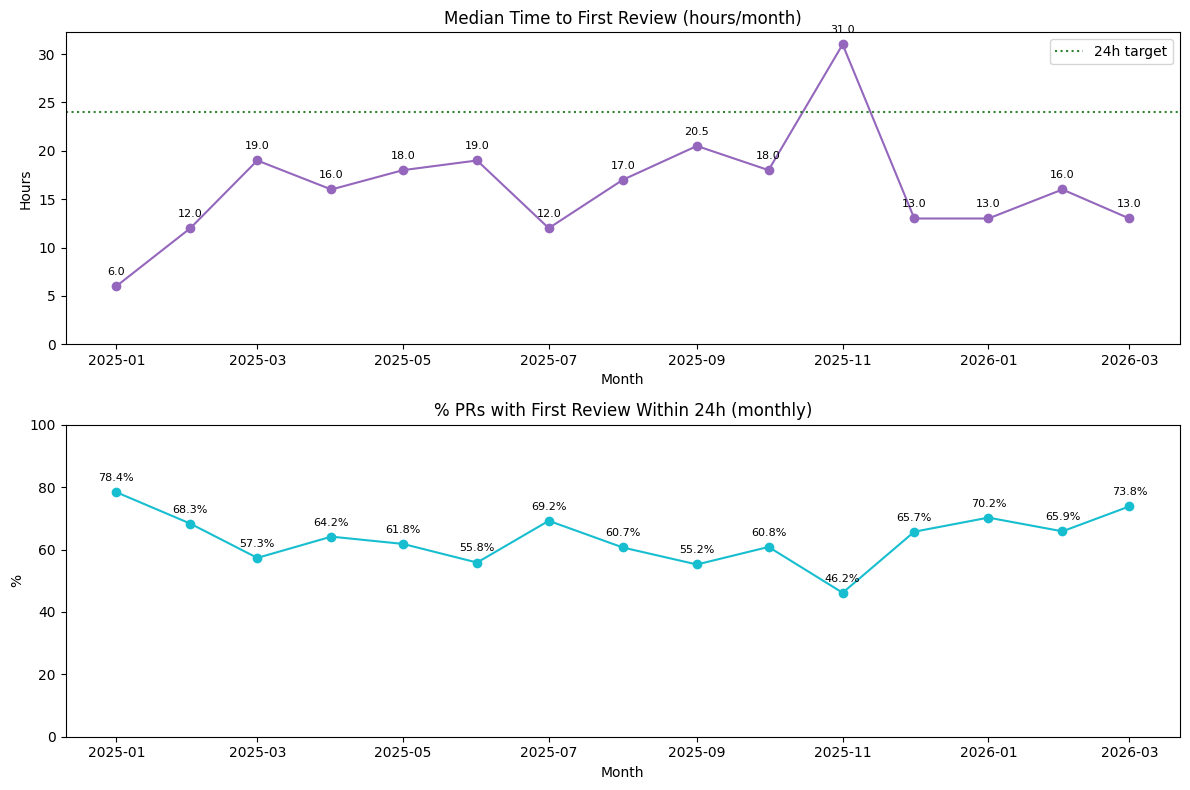

In [34]:
df_review = conn.sql("""
    SELECT
        creation_month,
        median_time_to_first_review_hours,
        pct_reviewed_within_24h
    FROM main_kpi.kpi_time_to_first_review
    ORDER BY creation_month
""").df()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(df_review["creation_month"], df_review["median_time_to_first_review_hours"],
         marker="o", color="tab:purple")
ax1.axhline(24, color="darkgreen", linestyle=":", alpha=0.8, label="24h target")
ax1.set_title("Median Time to First Review (hours/month)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Hours")
ax1.set_ylim(bottom=0)
ax1.tick_params(axis="x")
ax1.legend()
for month, val in zip(df_review["creation_month"], df_review["median_time_to_first_review_hours"]):
    ax1.annotate(f"{val:.1f}", xy=(month, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)

ax2.plot(df_review["creation_month"], df_review["pct_reviewed_within_24h"]*100,
        marker="o", color="tab:cyan")
ax2.set_title("% PRs with First Review Within 24h (monthly)")
ax2.set_xlabel("Month")
ax2.set_ylabel("%")
ax2.set_ylim(0, 100)
ax2.tick_params(axis="x")
for month, val in zip(df_review["creation_month"], df_review["pct_reviewed_within_24h"]*100):
    ax2.annotate(f"{val:.1f}%", xy=(month, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

### KPI 3 **Bug Resolution Time**

**Definition:** median hours from bug issue opened → closed (completed bugs only)   
**Excludes:** bot-filed issues, issues closed as duplicate or won't-fix     
**Quarterly grain:** monthly would be too noisy given the bug volume    



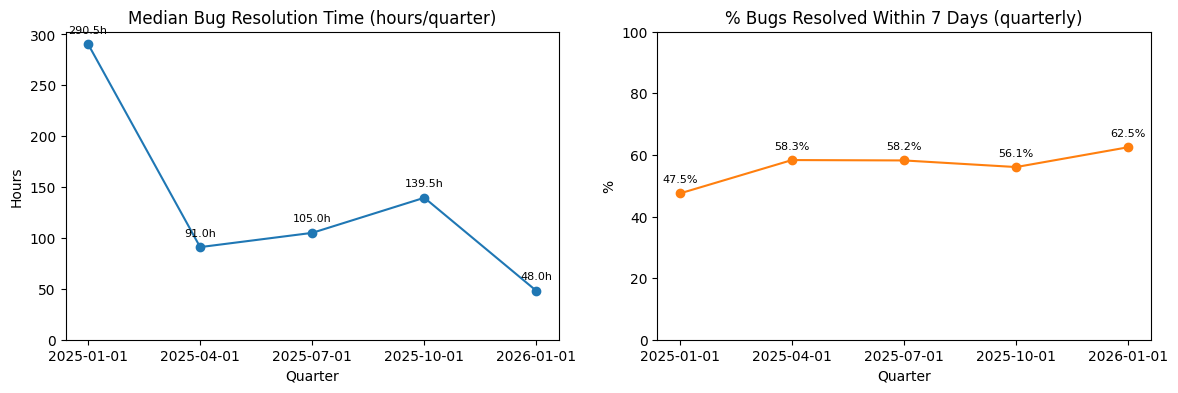

In [51]:
df_bug_time = conn.sql("""
    SELECT creation_quarter, median_hours_to_resolve, pct_resolved_within_7d
    FROM main_kpi.kpi_bug_resolution_time
    ORDER BY creation_quarter
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(df_bug_time["creation_quarter"].astype(str), df_bug_time["median_hours_to_resolve"],
         marker="o", color="tab:blue")
ax1.set_title("Median Bug Resolution Time (hours/quarter)")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Hours")
ax1.set_ylim(bottom=0)
ax1.tick_params(axis="x")
for q, val in zip(df_bug_time["creation_quarter"].astype(str), df_bug_time["median_hours_to_resolve"]):
    ax1.annotate(f"{val:.1f}h", xy=(q, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)

ax2.plot(df_bug_time["creation_quarter"].astype(str), df_bug_time["pct_resolved_within_7d"] * 100,
         marker="o", color="tab:orange")
ax2.set_title("% Bugs Resolved Within 7 Days (quarterly)")
ax2.set_xlabel("Quarter")
ax2.set_ylabel("%")
ax2.set_ylim(0, 100)
ax2.tick_params(axis="x")
for q, val in zip(df_bug_time["creation_quarter"].astype(str), df_bug_time["pct_resolved_within_7d"] * 100):
    ax2.annotate(f"{val:.1f}%", xy=(q, val), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)


Because the median resolution time is measured by quarter, it’s good for seeing long-term trends but not as helpful for tracking short-term progress or quick changes.

That’s why I also added a **weekly view of fixed bugs, grouped by how many days they took to fix (7/14/30 days)**. 
This view can go on a dashboard so teams can watch progress and notice delays sooner, which helps them decide faster.

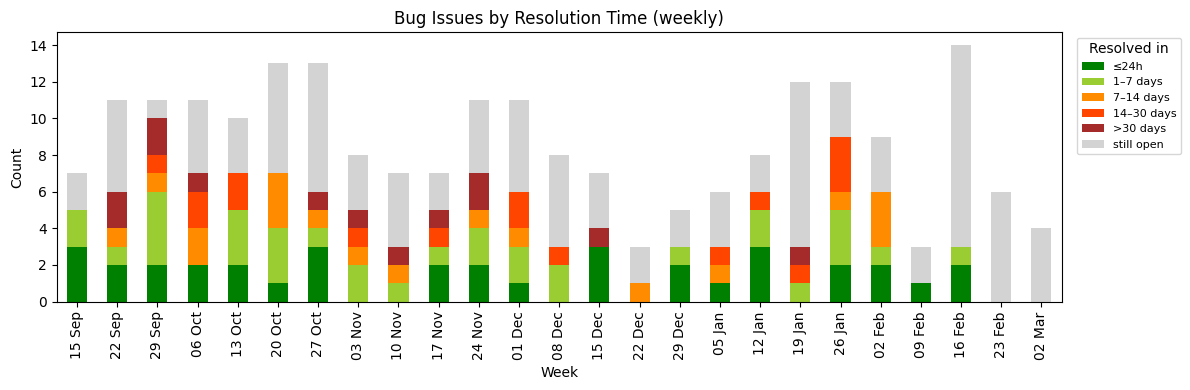

In [36]:
df_bug_bkt = conn.sql("""
    SELECT creation_week, resolution_bucket, bug_count
    FROM main_kpi.kpi_bug_resolution_buckets
    WHERE creation_week >= current_date() - interval 6 months
    ORDER BY creation_week
""").df()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

bucket_order  = ["within_24h", "within_7_days", "within_14_days", "within_30_days", "over_30_days", "open"]
bucket_labels = ["≤24h", "1–7 days", "7–14 days", "14–30 days", ">30 days", "still open"]
colors        = ["green", "yellowgreen", "darkorange", "orangered", "brown", "lightgrey"]

pivot_bkt = df_bug_bkt.pivot(index="creation_week", columns="resolution_bucket", values="bug_count") \
                      .reindex(columns=bucket_order, fill_value=0)
pivot_bkt.columns = bucket_labels
pivot_bkt.index = pd.to_datetime(pivot_bkt.index).strftime("%d %b")
pivot_bkt.plot(kind="bar", stacked=True, ax=ax, color=colors)
ax.set_title("Bug Issues by Resolution Time (weekly)")
ax.set_xlabel("Week")
ax.set_ylabel("Count")
ax.tick_params(axis="x")
ax.legend(title="Resolved in", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [37]:
conn.close()

---
## 5. Data Quality & Validation

### dbt tests

Every model has `not_null` and `unique` tests on its primary key. Key additional checks:

| Test | Model | What it catches |
|------|-------|----------------|
| `not_null` + `unique` on all PKs | all staging & mart models | Missing IDs, duplicate loads |
| `accepted_values(pr_state: open, closed)` | `stg_pull_requests` | Unexpected state values from the API |
| `relationships` (FK → `dim_contributors`) | `fct_pull_requests`, `fct_issues` | Orphaned fact rows |
| **Custom:** `merged_at >= created_at` | `stg_pull_requests` | Impossible timestamps / data corruption |

### Filtering rules built into the models

- **Bot filtering** - `author_type = 'User'` in all fact models. GitHub's API marks bot accounts with `type = 'Bot'` - used directly, no fragile name-based blocklist needed
- **Draft PRs excluded** - `is_draft = false` in `fct_github__pull_requests`. Draft PRs aren't in review yet and would inflate cycle time
- **Bot reviewers excluded** - `reviewer_type = 'User'` when computing time to first review
- **Invalid cycle times** - `cycle_time_hours > 0` guards against edge cases where merge and open timestamps are identical
- **Bug filter** - `list_contains(label_names, 'Bug')` - exact label match, no fuzzy logic
- **Completed bugs only** - `state_reason = 'completed'` excludes duplicates and won't-fix closures from the resolution KPI

### Contributor deduplication

The same GitHub user can show up across all four event types. The `contributor_key` macro builds a consistent surrogate key with a fallback chain:

1. **GitHub numeric ID** - most reliable; survives login renames
2. **Login** prefixed with `'login_'` - prevents accidental collision with numeric-looking login strings
3. **Email** prefixed with `'email_'` - last resort for commit data without a linked GitHub account

---
## 6. Production Improvements

Things that would need to change before this runs reliably in production:

- **Incremental loading**   
Every run currently does a full DELETE + INSERT. For a large or busy repo this doesn't scale. The fix: watermark-based extraction (only fetch records updated since the last run) combined with dbt incremental models to merge new rows cleanly.

- **Orchestration & scheduling**    
The pipeline is a manual `python run_pipeline.py` call today. Production needs a scheduler - dbt Cloud, Airflow, or Prefect - with retry logic, SLA monitoring, and failure alerts.

- **CI/CD for dbt**     
Tests run manually right now. In production they should run automatically on every PR via GitHub Actions - a failing test should block a merge, not surface after deployment.

- **Secret management**     
The GitHub token lives in a `.env` file, which is fine locally but not in production. The fix: environment variables injected at runtime, or a dedicated secrets manager (AWS Secrets Manager, GCP Secret Manager, etc.).

- **Data freshness monitoring**     
Add `freshness` configs to dbt sources so the pipeline fails loudly - and triggers an alert - if raw tables haven't been updated within the expected window.

- **Schema evolution handling**     
GitHub occasionally adds or renames API fields. Raw JSON storage protects against data loss, but staging SQL would still need updating. A column diff check or schema registry would surface breaking changes early.

- **Rate limit resilience**     
The current retry logic waits for the rate limit reset and retries once. Production should checkpoint extraction progress so a mid-run failure doesn't require starting from scratch.

- **dbt documentation**     
`dbt docs generate` produces a full lineage graph and column-level docs. Worth hosting so anyone on the team can understand the models without reading the SQL.

---
## 7. Appendix: Analytical Details

How the KPI thresholds and filtering decisions above were derived from the actual data.

### PR Size Buckets

I chose 50 and 250 lines as thresholds based on practical experience, not strict percentiles.

Most PRs are small in the chosen repository. The median PR size is 31 changed lines.

If I used the 33rd and 66th percentiles, small would be ≤16 lines and medium ≤54, but these cutoffs are not practical. A 15-line and a 20-line PR are practically the same, so those boundaries aren't helpful.

That’s why I chose thresholds that make more sense in real situations:

* Small (≤50 lines): simple, quick review
* Medium (51 - 250 lines): larger changes that need a thorough review
* Large (>250 lines): big pull requests

Large PRs (>250 lines) appear fewer than 15 times per month - too few for a reliable monthly median, so they're excluded from the median calculation.

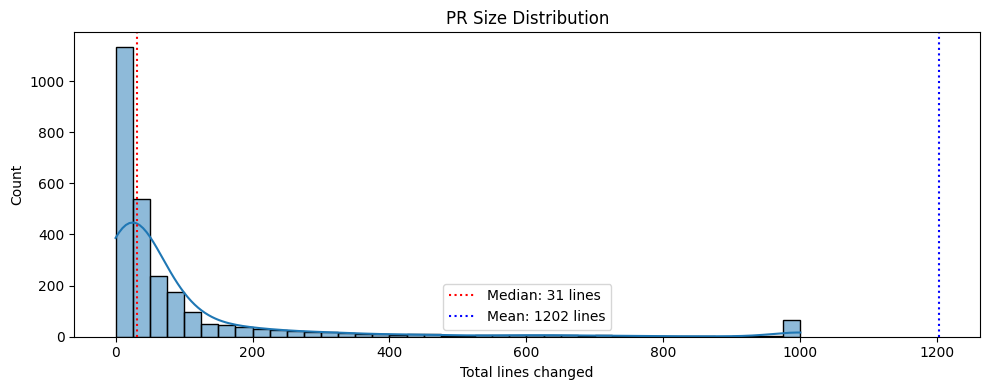

Percentile,p25,p33,p50,p66,p75,p90,p95
Lines changed,11,16,31,54,81,240,493


In [38]:
conn2 = duckdb.connect("../database/analytics.db")

df_size = conn2.sql("""
    SELECT total_changes
    FROM main_marts.fct_github__pull_requests
    WHERE total_changes IS NOT NULL
      AND created_at::date >= '2025-01-01'::date
""").df()

s = df_size["total_changes"]
median_val = s.median()
mean_val = s.mean()
capped = s.clip(upper=1000)
n_over = int((s > 1000).sum())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(capped, bins=40, kde=True, ax=ax)

ax.axvline(median_val, color="red", linestyle=":",
           label=f"Median: {median_val:.0f} lines")
ax.axvline(mean_val,   color="blue",    linestyle=":",
           label=f"Mean: {mean_val:.0f} lines")
ax.set_title(f"PR Size Distribution")
ax.set_xlabel("Total lines changed")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

# Percentile table
pct_levels = [25, 33, 50, 66, 75, 90, 95]
pct_df = pd.DataFrame({
    "Percentile": [f"p{p}" for p in pct_levels],
    "Lines changed": [int(s.quantile(p / 100)) for p in pct_levels],
})
display(pct_df.set_index("Percentile").T)

### Cycle Time Outlier Cutoff

PRs open >30 days (~720h) are excluded from `kpi_cycle_time`. They represent stale branches or long-running feature work - not typical workflow.

The distribution is heavily right-skewed: **median ~19h, mean ~65h** (3.5× gap). Median is the right measure - mean is too sensitive to the long tail.

Excluded outliers (>30 days): 83 PRs (5.0% of total)


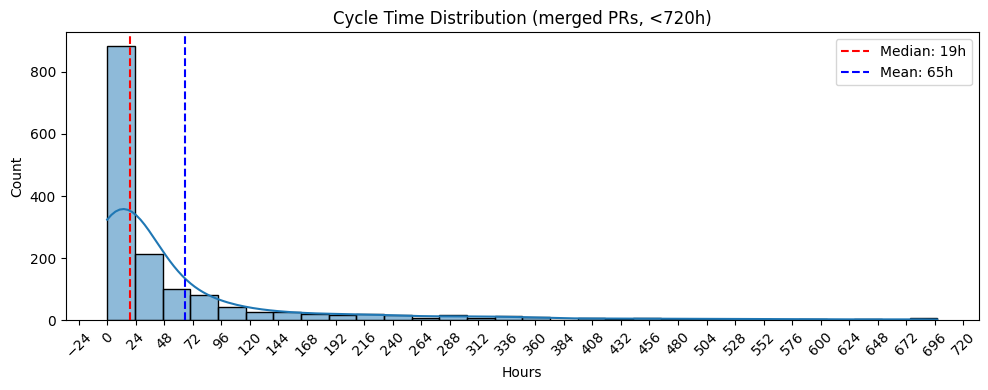

In [39]:
df_cycle_raw = conn2.sql("""
    SELECT cycle_time_hours
    FROM main_marts.fct_github__pull_requests
    WHERE is_merged = true
      AND cycle_time_hours IS NOT NULL
      AND cycle_time_hours < 720
      AND created_at::date >= '2025-01-01'::date
""").df()

n_outliers = conn2.sql("""
    SELECT COUNT(*) AS n
    FROM main_marts.fct_github__pull_requests
    WHERE is_merged = true
      AND cycle_time_hours >= 720
      AND created_at::date >= '2025-01-01'::date
""").df()["n"][0]

total = len(df_cycle_raw) + n_outliers
print(f"Excluded outliers (>30 days): {n_outliers} PRs ({n_outliers / total * 100:.1f}% of total)")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_cycle_raw["cycle_time_hours"], bins=30, kde=True, ax=ax)
ax.axvline(df_cycle_raw["cycle_time_hours"].median(), color="red",  linestyle="--",
           label=f'Median: {df_cycle_raw["cycle_time_hours"].median():.0f}h')
ax.axvline(df_cycle_raw["cycle_time_hours"].mean(),   color="blue", linestyle="--",
           label=f'Mean: {df_cycle_raw["cycle_time_hours"].mean():.0f}h')
ax.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax.tick_params(axis="x", rotation=45)
ax.set_title("Cycle Time Distribution (merged PRs, <720h)")
ax.set_xlabel("Hours")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

### 24h Review Benchmark

Median time to first review is ~15h. 24h sits just above it and represents one full working day - PRs reviewed within 24h didn't experience a meaningful wait. Used as a reference line in KPI 2.

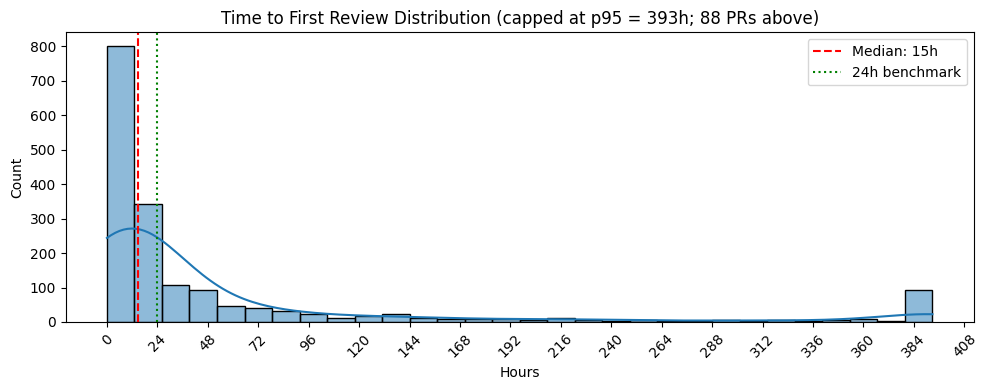

In [40]:
df_rev_raw = conn2.sql("""
    SELECT time_to_first_review_hours
    FROM main_marts.fct_github__pull_requests
    WHERE time_to_first_review_hours IS NOT NULL
      AND created_at::date >= '2025-01-01'::date
""").df()

cap     = df_rev_raw["time_to_first_review_hours"].quantile(0.95)
clipped = df_rev_raw["time_to_first_review_hours"].clip(upper=cap)
n_cap   = int((df_rev_raw["time_to_first_review_hours"] > cap).sum())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(clipped, bins=30, kde=True, ax=ax)
ax.axvline(clipped.median(), color="red",   linestyle="--",
           label=f'Median: {clipped.median():.0f}h')
ax.axvline(24,               color="green", linestyle=":", label="24h benchmark")
ax.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax.tick_params(axis="x", rotation=45)
ax.set_title(f"Time to First Review Distribution (capped at p95 = {cap:.0f}h; {n_cap} PRs above)")
ax.set_xlabel("Hours")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

### Issues by Label

Shows how issues are distributed across label types - context for the bug KPIs. How big is the bug slice relative to everything else?

In [41]:
df_tags = conn2.sql("""
    SELECT
    label,
    COUNT(*) AS issue_count
FROM main_marts.fct_github__issues,
    UNNEST(label_names) AS t(label)
WHERE created_at::date >= '2025-01-01'::date
GROUP BY 1
ORDER BY 2 DESC
""").df()

display(df_tags)

,label,issue_count
0,Bug,527
1,Needs Triage,231
2,Enhancement,171
3,Docs,154
4,Needs Discussion,103
...,...,...
121,Complex,1
122,rename,1
123,Multithreading,1
124,Downcasting,1


### Bug Resolution Distribution

Right-skewed - most bugs close quickly, a long tail drags the mean. Median is the right central measure. The wide spread justifies tracking both a median and a bucket breakdown.

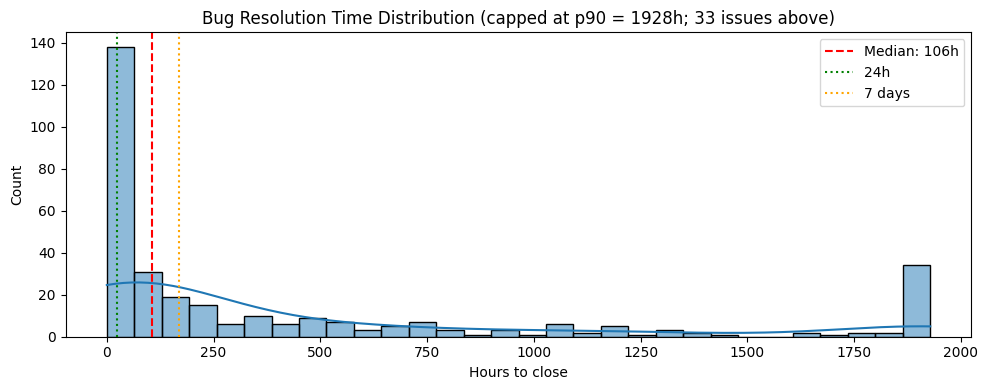

In [42]:
df_bugs_raw = conn2.sql("""
    SELECT hours_to_close
    FROM main_marts.fct_github__issues
    WHERE is_bug = true
      AND is_resolved = true
      AND hours_to_close >= 0
      AND created_at::date >= '2025-01-01'::date
""").df()

cap_b     = df_bugs_raw["hours_to_close"].quantile(0.90)
clipped_b = df_bugs_raw["hours_to_close"].astype(float).clip(upper=cap_b)
n_cap_b   = int((df_bugs_raw["hours_to_close"] > cap_b).sum())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(clipped_b, bins=30, kde=True, ax=ax)
ax.axvline(clipped_b.median(), color="red",    linestyle="--",
           label=f'Median: {clipped_b.median():.0f}h')
ax.axvline(24,                 color="green",  linestyle=":", label="24h")
ax.axvline(168,                color="orange", linestyle=":", label="7 days")
ax.set_title(f"Bug Resolution Time Distribution (capped at p90 = {cap_b:.0f}h; {n_cap_b} issues above)")
ax.set_xlabel("Hours to close")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
conn2.close()